In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd "/content/drive/MyDrive/meta_data"

/content/drive/MyDrive/meta_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from joblib import dump, load

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, cross_validate, cross_val_predict
from scipy.stats import randint, uniform, loguniform

In [ ]:
df = pd.read_pickle('preprocessed_data_demand_forecast.pkl')

In [ ]:
df.head()

,Demand,product_total_demand,avg_product_price,country_total_demand,country_order_count,category_avg_demand,avg_customer_orders,avg_shipping_time,country_avg_demand,year_month,ProductCardId,OrderCountry,avg_discount_rate,avg_late_delivery_risk
0,0.097575,0.014195,0.092598,0.194908,0.229465,0.898963,0.545455,-0.110725,0.500253,2015-01,37,Colombia,0.111042,1.0
1,0.226562,0.014195,0.092598,0.306198,0.192960,0.898963,0.000000,-0.686770,0.523892,2015-01,37,Guatemala,0.111042,1.0
2,0.057078,0.014195,0.092598,1.000000,1.000000,0.898963,0.993103,0.051479,0.472666,2015-01,37,México,0.111042,1.0
3,0.128987,0.014195,0.092598,0.406219,0.362451,0.898963,0.345324,0.979394,0.607339,2015-01,37,República Dominicana,0.111042,1.0
4,0.252228,0.017103,0.185195,0.875528,0.659713,0.898963,0.189723,0.536652,0.412964,2015-01,44,Brasil,0.097333,0.5


In [ ]:
# Load the pipeline from the file
pipeline = load('demand_forecast_pipeline.pkl')

### Split dataset into train and test sets

In [ ]:
y = df['Demand']
X = df.drop(columns='Demand')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Saving the train and test datasets as pickle for future evaluation

In [ ]:
# Save training data
with open('train_data.pkl', 'wb') as f:
    pickle.dump((X_train, y_train), f)

# Save testing data
with open('test_data.pkl', 'wb') as f:
    pickle.dump((X_test, y_test), f)

In [ ]:
droped_columns = ['ProductCardId', 'year_month', 'OrderCountry']
X.drop(columns=droped_columns, inplace=True)
X_train.drop(columns=droped_columns, inplace=True)
X_test.drop(columns=droped_columns, inplace=True)

Since our target variable ("Demand") is continuous, there are several Regression models we can experiment with.

1. Linear Regression
2. Polynomial Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor
6. XGBoost Regressor
7. Support Vector Regressor (SVR)
8. K-Nearest Neighbors (KNN) Regressor
9. Neural Networks (MLPRegressor)

In [ ]:
# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression': Pipeline(steps=[
        ('poly_features', PolynomialFeatures(degree=2)),
        ('linear_reg', LinearRegression())
    ]),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=3),
    'Neural Network': MLPRegressor(random_state=42)
}

### Train, Testing and Evaluation

In [ ]:
def evaluation_matrix(model_name, y_test, y_pred):
    # Evaluate model performance
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) # Calculate RMSE manually
    r2 = r2_score(y_test, y_pred)

    # Store the results
    return {
        'Model': model_name,
        'Mean Absolute Error (MAE)': mae,
        'Mean Squared Error': mse,
        'Root Mean Squared Error (RMSE)': rmse,
        'R-squared': r2
    }

In [ ]:
# store trained model's prediction on dictionary
trained_models = {}
# Store evaluation metrics
eval_matrix = []

for model_name, model in models.items():
  print(f"=== {model_name} ===")

  # Train the model (fit the entire pipeline)
  model.fit(X_train, y_train)

  # Make predictions using the final estimator on the transformed test data
  y_pred = model.predict(X_test)

  # we stored models prediction, so that later we can visualize it
  trained_models[model_name] = y_pred

  # Store the results
  eval_matrix.append(evaluation_matrix(model_name, y_test, y_pred))

  print("Done.\n")

=== Linear Regression ===
Done.

=== Polynomial Regression ===
Done.

=== Decision Tree ===
Done.

=== Random Forest ===
Done.

=== Gradient Boosting ===
Done.

=== XGBoost ===
Done.

=== Support Vector Regressor ===
Done.

=== K-Nearest Neighbors ===
Done.

=== Neural Network ===
Done.



In [ ]:
# Convert results to a DataFrame for better visualization
eval_matrix_df = pd.DataFrame(eval_matrix)
eval_matrix_df

,Model,Mean Absolute Error (MAE),Mean Squared Error,Root Mean Squared Error (RMSE),R-squared
0,Linear Regression,0.096092,0.014057,0.118562,0.509999
1,Polynomial Regression,0.059797,0.005719,0.075621,0.800662
2,Decision Tree,0.057742,0.006104,0.078129,0.787222
3,Random Forest,0.043441,0.003282,0.057286,0.885604
4,Gradient Boosting,0.044515,0.003398,0.058290,0.881561
5,XGBoost,0.044452,0.003391,0.058230,0.881805
6,Support Vector Regressor,0.055429,0.004768,0.069051,0.833797
7,K-Nearest Neighbors,0.060614,0.006236,0.078970,0.782615
8,Neural Network,0.052889,0.004705,0.068590,0.836004


Lower MAE, MSE, and RMSE indicate better performance, as these metrics measure the error between the predicted and actual values.

Higher R-squared indicates a better fit of the model to the data, meaning the model explains a larger proportion of the variance in the target variable.

Based on these metrics, the Gradient Boosting, Random Forest, and XGBoost models seem to be performing the best, as they have the lowest MAE, MSE, and RMSE, and the highest R-squared values. The Linear Regression model performs the worst among all the models.

### Cross Validation (fold=5)

In [ ]:
# Define CV splitter
# Use KFold for regression tasks
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Choose the metric
scoring = {
    'mae': make_scorer(mean_absolute_error),
    'mse': make_scorer(mean_squared_error),
    #'rmse': make_scorer(mean_squared_error, squared=False), # Add RMSE explicitly
    'r2': make_scorer(r2_score),
    'neg_mse': make_scorer(mean_squared_error, greater_is_better=False) # Explicitly add negative MSE
}

In [ ]:
# Loop over models
for name, model in models.items():
    print(f"\n=== {name} ===")

    # cross‐validate to get metric distributions
    cv_results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    # Print mean ± std for each metric
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

    # Using cross_val_predict, you get an “out‑of‑fold” prediction for every row
    # This runs an out‐of‐fold prediction on each sample
    #y_pred_oof = cross_val_predict(model, X, y, cv=cv)

    print("Done.\n")


=== Linear Regression ===
mae: 0.095 ± 0.001
mse: 0.014 ± 0.000
r2: 0.526 ± 0.013
neg_mse: -0.014 ± 0.000
Done.


=== Polynomial Regression ===
mae: 0.059 ± 0.001
mse: 0.005 ± 0.000
r2: 0.811 ± 0.006
neg_mse: -0.005 ± 0.000
Done.


=== Decision Tree ===
mae: 0.058 ± 0.001
mse: 0.006 ± 0.000
r2: 0.785 ± 0.005
neg_mse: -0.006 ± 0.000
Done.


=== Random Forest ===
mae: 0.044 ± 0.001
mse: 0.003 ± 0.000
r2: 0.885 ± 0.004
neg_mse: -0.003 ± 0.000
Done.


=== Gradient Boosting ===
mae: 0.044 ± 0.001
mse: 0.003 ± 0.000
r2: 0.886 ± 0.003
neg_mse: -0.003 ± 0.000
Done.


=== XGBoost ===
mae: 0.044 ± 0.001
mse: 0.003 ± 0.000
r2: 0.884 ± 0.004
neg_mse: -0.003 ± 0.000
Done.


=== Support Vector Regressor ===
mae: 0.056 ± 0.001
mse: 0.005 ± 0.000
r2: 0.837 ± 0.005
neg_mse: -0.005 ± 0.000
Done.


=== K-Nearest Neighbors ===
mae: 0.060 ± 0.001
mse: 0.006 ± 0.000
r2: 0.786 ± 0.006
neg_mse: -0.006 ± 0.000
Done.


=== Neural Network ===
mae: 0.053 ± 0.001
mse: 0.005 ± 0.000
r2: 0.838 ± 0.005
neg_mse: -0.0

For 'Linear Regression' and 'Polynomial Regression', they generally don't have hyperparameters that are tuned using methods like RandomizedSearchCV in the same way as other models.

In [ ]:
# Define parameter grids for each model
param_grids = {
    'Decision Tree': {
        'max_depth': randint(1, 50),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': ['sqrt', 'log2', None]
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(5, 50),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': uniform(0.3, 0.7)
    },
    'Gradient Boosting': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 15),
        'subsample': uniform(0.5, 0.5),
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': randint(50, 300),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 5),
        'reg_alpha': loguniform(1e-8, 1e2),
        'reg_lambda': loguniform(1e-8, 1e2)
    },
    'Support Vector Regressor': {
        'C': loguniform(1e-2, 1e3),
        'epsilon': loguniform(1e-3, 1e1),
        'gamma': ['scale', 'auto'] + list(loguniform(1e-4, 1e1).rvs(5))
    },
    'K-Nearest Neighbors': {
        'n_neighbors': randint(3, 30),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Neural Network': {
        'hidden_layer_sizes': [(randint.rvs(50,200),), (randint.rvs(50,200), randint.rvs(20,100))],
        'activation': ['tanh', 'relu', 'logistic'],
        'solver': ['adam', 'sgd'],
        'alpha': loguniform(1e-5, 1e-1),
        'learning_rate_init': uniform(1e-4, 1e-1)
    }
}

In [ ]:
# Dictionary to store the best models after tuning
best_models = {}
entire_cv_resut = {}

# Perform hyperparameter tuning on each model with the pipeline
for name, model in models.items():
    # Skip Linear and Polynomial Regression as they are not typically tuned with RandomizedSearchCV
    if name == 'Linear Regression' or name == 'Polynomial Regression':
        continue

    print(f"Tuning {name}...")

    # Use either GridSearchCV or RandomizedSearchCV depending on the model
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    n_iter=100,                  # number of different combinations to try
    scoring=scoring, # Use the scoring dictionary for multiple metrics
    refit='neg_mse', # Specify which metric to use for refitting the best model
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42,
    error_score='raise'                    # will stop immediately on invalid params
    )

    # Fit the search to the data
    random_search.fit(X_train, y_train)
    best_models[name] = random_search.best_estimator_
    entire_cv_resut[name] = random_search

    print(f"Best parameters for {name}: {random_search.best_params_}")

    # Get the best R-squared score for the best parameters
    best_index = random_search.best_index_
    # Access the mean test R-squared score using the key from the scoring dictionary
    best_r2 = random_search.cv_results_['mean_test_r2'][best_index]
    print(f"Best R-squared for {name}: {best_r2:.3f}")

Tuning Decision Tree...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters for Decision Tree: {'max_depth': 39, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 12}
Best R-squared for Decision Tree: 0.831
Tuning Random Forest...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters for Random Forest: {'max_depth': 43, 'max_features': np.float64(0.8575800908021629), 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 171}
Best R-squared for Random Forest: 0.884
Tuning Gradient Boosting...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters for Gradient Boosting: {'learning_rate': np.float64(0.05679835610086079), 'max_depth': 13, 'max_features': None, 'n_estimators': 137, 'subsample': np.float64(0.6668543055695109)}
Best R-squared for Gradient Boosting: 0.875
Tuning XGBoost...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters for XGBoost: {'colsample_bytree': 

### Evaluation

In [ ]:
# Evaluate each model on the test set
eval_matrix = []
for name, model in best_models.items():
    # Predict on the test set
    y_pred = model.predict(X_test)

    eval_matrix.append(evaluation_matrix(name, y_test, y_pred))

# Convert results to a DataFrame for better visualization
eval_matrix_df = pd.DataFrame(eval_matrix)
eval_matrix_df

,Model,Mean Absolute Error (MAE),Mean Squared Error,Root Mean Squared Error (RMSE),R-squared
0,Decision Tree,0.051260,0.004819,0.069416,0.832032
1,Random Forest,0.043566,0.003257,0.057074,0.886453
2,Gradient Boosting,0.045103,0.003557,0.059643,0.876001
3,XGBoost,0.053878,0.004708,0.068613,0.835894
4,Support Vector Regressor,0.078384,0.009153,0.095672,0.680935
5,K-Nearest Neighbors,0.056777,0.005323,0.072959,0.814447
6,Neural Network,0.053266,0.004906,0.070046,0.828972


Save the models and also the entire optimisation object for visualisation and further evaluation

In [ ]:
# Save each model
for name, model in best_models.items():
  dump(model, f'{name}_model.joblib')

### Comparison of the models based on Visualisation

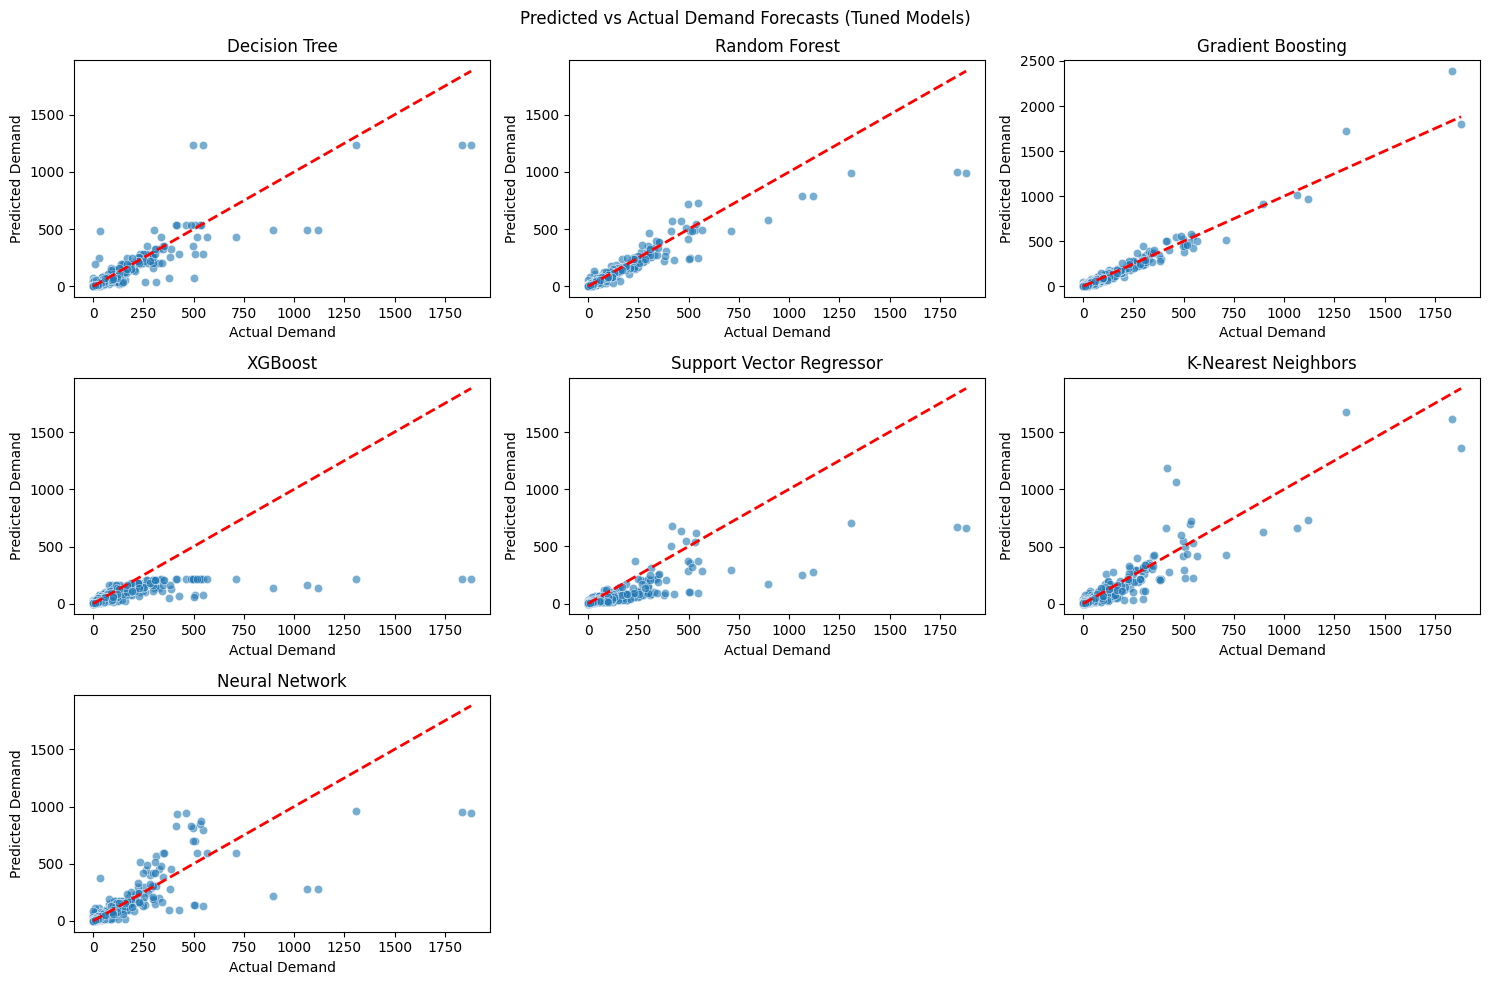

In [ ]:
# Plot Actual vs Predicted demands for the best models after tuning
plt.figure(figsize=(15, 10))
plt.suptitle('Predicted vs Actual Demand Forecasts (Tuned Models)')

# The pipeline contains a step named 'norm' with MinMaxScaler
# Inverse MinMax scaling and then inverse log transformation for y_test
# We need to reshape y_test as inverse_transform expects a 2D array
y_test_reshaped = y_test.values.reshape(-1, 1)
y_test_denormalized = pipeline.named_steps['preprocess'].named_transformers_['norm_target'].inverse_transform(y_test_reshaped)
y_test_unscaled = np.expm1(y_test_denormalized.flatten())


# Create a subplot for each best model's predictions
for i, (name, model) in enumerate(best_models.items(), 1):
    plt.subplot(3, 3, i)

    # Make predictions with the best model
    y_pred = model.predict(X_test)

    # Inverse MinMax scaling and then inverse log transformation for y_pred
    # We need to reshape y_pred as inverse_transform expects a 2D array
    y_pred_reshaped = y_pred.reshape(-1, 1)
    y_pred_denormalized = pipeline.named_steps['preprocess'].named_transformers_['norm_target'].inverse_transform(y_pred_reshaped)
    y_pred_unscaled = np.expm1(y_pred_denormalized.flatten())

    sns.scatterplot(x=y_test_unscaled, y=y_pred_unscaled, alpha=0.6)
    plt.plot([y_test_unscaled.min(), y_test_unscaled.max()], [y_test_unscaled.min(), y_test_unscaled.max()], 'r--', lw=2)  # 45-degree line
    plt.xlabel('Actual Demand')
    plt.ylabel('Predicted Demand')
    plt.title(name)

plt.tight_layout()
plt.show()